Data Gathering

In [ ]:
# CELL 0: SETUP & DEPENDENCIES
!pip install -q osmnx geopandas shapely requests pandas numpy matplotlib openpyxl

import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
import json
import os
from getpass import getpass

# Create dataset directory
DATA_DIR = '/content/drive/MyDrive/bescom_dataset'
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Setup complete! Files will be saved to {DATA_DIR}")

Setup complete! Files will be saved to /content/drive/MyDrive/bescom_dataset


In [ ]:
import os
import osmnx as ox
import geopandas as gpd
import pandas as pd

print("Fetching real map data for Bengaluru from OSM. Please wait (~1-2 mins)...")

# Increase timeout for large city queries
ox.settings.timeout = 300

place_name = "Bengaluru, Karnataka, India"
tags = {'landuse': ['residential', 'commercial']}

# Ensure the DATA_DIR from CELL 0 is used
os.makedirs(DATA_DIR, exist_ok=True)

try:
    # Fetch polygons
    gdf_zones = ox.features_from_place(place_name, tags=tags)

    # Keep only polygon geometries
    gdf_zones = gdf_zones[gdf_zones.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()

    # Reset index so OSM identifiers become columns if present
    gdf_zones = gdf_zones.reset_index()

    print("Columns returned by OSMnx:", list(gdf_zones.columns))

    # Find a usable ID column
    id_col = None
    for candidate in ["osmid", "id", "element_type"]:
        if candidate in gdf_zones.columns:
            id_col = candidate
            break

    # Create zone_id safely
    if id_col is not None:
        gdf_zones["zone_id"] = gdf_zones[id_col].astype(str)
    else:
        gdf_zones["zone_id"] = ["zone_" + str(i) for i in range(len(gdf_zones))]

    # Keep only useful columns that actually exist
    keep_cols = []
    for col in ["zone_id", "osmid", "id", "element_type", "landuse", "name", "geometry"]:
        if col in gdf_zones.columns:
            keep_cols.append(col)

    gdf_zones = gdf_zones[keep_cols].copy()

    # Save GeoJSON for mapping
    geojson_path = f"{DATA_DIR}/bengaluru_zones.geojson"
    gdf_zones.to_file(geojson_path, driver="GeoJSON")

    # Save CSV for ML use (drop geometry)
    df_zones = gdf_zones.drop(columns=["geometry"]).copy()

    # Convert everything to string for safe CSV export
    for col in df_zones.columns:
        df_zones[col] = df_zones[col].astype(str)

    csv_path = f"{DATA_DIR}/bengaluru_zones.csv"
    df_zones.to_csv(csv_path, index=False)

    print(f"✅ Success! Extracted {len(gdf_zones)} zones.")
    print(f"Saved GeoJSON: {geojson_path}")
    print(f"Saved CSV: {csv_path}")

except Exception as e:
    print(f"❌ Error fetching OSM data: {e}")

Fetching real map data for Bengaluru from OSM. Please wait (~1-2 mins)...
Columns returned by OSMnx: ['element', 'id', 'geometry', 'created_by', 'landuse', 'name', 'addr:city', 'addr:postcode', 'air_conditioning', 'fax', 'office', 'phone', 'smoking', 'url', 'website', 'wheelchair', 'addr:street', 'government', 'name:kn', 'amenity', 'brand', 'brand:short', 'brand:wikidata', 'operator', 'operator:short', 'operator:wikidata', 'post_office:type', 'addr:housename', 'residential', 'addr:housenumber', 'description', 'ele', 'source', 'start_date', 'developer', 'addr:district', 'addr:full', 'image', 'building', 'alt_name', 'int_name', 'old_name', 'wikidata', 'wikipedia', 'place', 'short_name', 'barrier', 'tourism', 'official_name', 'wikimedia_commons', 'full_name', 'access', 'fixme', 'architect', 'emergency', 'healthcare', 'note', 'FIXME', 'shop', 'addr:country', 'addr:hamlet', 'addr:suburb', 'email', 'internet_access', 'internet_access:fee', 'rooms', 'stars', 'name:etymology:wikidata', 'herita

In [ ]:
# CELL 2: EXTRACT EXISTING CHARGERS (OpenChargeMap API) - ROBUST VERSION

import os
import requests
import pandas as pd

print("--- OpenChargeMap API ---")
print("Get your free key here: https://openchargemap.org/site/develop/api")

ocm_key = "ef99e64a-f277-4b84-9f35-102137fa0b80"
chargers = []

def safe_get(d, *keys, default=None):
    """
    Safely fetch nested values from dictionaries.
    Returns default if any level is missing or None.
    """
    cur = d
    for key in keys:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(key)
        if cur is None:
            return default
    return cur

if ocm_key.strip():
    print("Fetching from OpenChargeMap...")

    url = "https://api.openchargemap.io/v3/poi/"
    params = {
        "key": ocm_key,
        "countrycode": "IN",
        # OCM usually works better with lat/lon bounds as separate params in some setups,
        # but maxresults alone is fine for a broad fetch.
        "maxresults": 500,
        "compact": True,
        "verbose": False
    }

    try:
        response = requests.get(
            url,
            params=params,
            headers={
                "User-Agent": "BengaluruEVHackathon/1.0"
            },
            timeout=60
        )
        response.raise_for_status()
        data = response.json()

        for poi in data:
            addr = poi.get("AddressInfo") or {}
            operator_info = poi.get("OperatorInfo") or {}

            lat = addr.get("Latitude")
            lon = addr.get("Longitude")

            # Skip records without coordinates
            if lat is None or lon is None:
                continue

            chargers.append({
                "charger_id": poi.get("ID"),
                "name": addr.get("Title", "Unknown"),
                "lat": lat,
                "lon": lon,
                "city": addr.get("Town", "Unknown"),
                "state": addr.get("StateOrProvince", "Unknown"),
                "operator": operator_info.get("Title", "Unknown"),
                "source": "OpenChargeMap"
            })

        print(f"✅ Downloaded {len(chargers)} chargers from OCM.")

    except Exception as e:
        print(f"❌ OCM API Failed: {e}")

else:
    print("No key provided. Fetching free charger data from OpenStreetMap...")
    overpass_url = "https://overpass-api.de/api/interpreter"
    query = """
    [out:json][timeout:60];
    area["name"="Bengaluru"]->.searchArea;
    node["amenity"="charging_station"](area.searchArea);
    out center;
    """
    try:
        response = requests.get(
            overpass_url,
            params={"data": query},
            headers={"User-Agent": "BengaluruEVHackathon/1.0"},
            timeout=120
        )
        response.raise_for_status()
        result = response.json()

        for element in result.get("elements", []):
            tags = element.get("tags") or {}
            chargers.append({
                "charger_id": element.get("id"),
                "name": tags.get("name", "Unknown"),
                "lat": element.get("lat"),
                "lon": element.get("lon"),
                "operator": tags.get("operator", "Unknown"),
                "source": "OSM"
            })

        print(f"✅ Downloaded {len(chargers)} chargers from OSM.")

    except Exception as e:
        print(f"❌ OSM fallback failed: {e}")

# Save to CSV
df_chargers = pd.DataFrame(chargers)
df_chargers.to_csv(f"{DATA_DIR}/existing_chargers.csv", index=False)

print(df_chargers.head())
print(f"Saved: {DATA_DIR}/existing_chargers.csv")

--- OpenChargeMap API ---
Get your free key here: https://openchargemap.org/site/develop/api
Fetching from OpenChargeMap...
✅ Downloaded 500 chargers from OCM.
   charger_id                                        name        lat  \
0      487809                                     Menu 99  10.337347   
1      486925  VeChaarge EV Charging Station - Hilly Aqua   9.857074   
2      485927                       Guntur - Chirala Road  16.230968   
3      485770                            Hotel Shri Durga  12.824969   
4      485543                  VeChaarge Charging Station  10.158963   

         lon        city           state operator         source  
0  77.957579     Unknown      Tamil Nadu  Unknown  OpenChargeMap  
1  76.729149      Muttam          Kerala  Unknown  OpenChargeMap  
2  80.509699     Unknown  Andhra Pradesh  Unknown  OpenChargeMap  
3  75.175437  Sathikallu       Karnataka  Unknown  OpenChargeMap  
4  76.358228      Athani          Kerala  Unknown  OpenChargeMap  
Saved

In [ ]:
# CELL 3: EV ADOPTION DATA (Proxy pending manual Vahan upload)
print("Generating Bengaluru RTO mapping and baseline EV proxy data...")

# Actual Bengaluru RTO Codes
blr_rtos = {
    'KA-01': 'Koramangala', 'KA-02': 'Rajajinagar', 'KA-03': 'Indiranagar',
    'KA-04': 'Yeshwanthpur', 'KA-05': 'Jayanagar', 'KA-41': 'Jnanabharathi',
    'KA-50': 'Yelahanka', 'KA-51': 'Electronics City', 'KA-53': 'KR Puram'
}

vahan_data = []
for rto_code, location in blr_rtos.items():
    vahan_data.append({
        'rto_code': rto_code,
        'location_name': location,
        # Realistic proxy numbers based on 2024 BLR EV density
        'registered_2w_evs': np.random.randint(5000, 25000),
        'registered_4w_evs': np.random.randint(1000, 8000)
    })

df_vahan = pd.DataFrame(vahan_data)
df_vahan.to_csv(f'{DATA_DIR}/vahan_ev_adoption_proxy.csv', index=False)
print(f"✅ Proxy Vahan data created for {len(blr_rtos)} RTOs. Replace this file later with your manual download.")

Generating Bengaluru RTO mapping and baseline EV proxy data...
✅ Proxy Vahan data created for 9 RTOs. Replace this file later with your manual download.


In [ ]:
# CELL 4: CHARGING BEHAVIOR DATA (FULL YEAR PULL WITH RETRIES)
import requests
import json
import pandas as pd
import numpy as np
import datetime
import os
import time # IMPORT TIME FOR RATE LIMITING
from urllib.parse import urljoin

DATA_DIR = '/content/drive/MyDrive/bescom_dataset'
os.makedirs(DATA_DIR, exist_ok=True)

print("--- ACN Caltech API (Massive Pull) ---")
acn_token = "ACN_API_KEY"
use_proxy = False

if acn_token.strip():
    print("Fetching full year of 2019 ACN-Data (Please wait 1-2 minutes)...")

    start_date = "2019-01-01T00:00:00Z"
    end_date = "2019-12-31T23:59:59Z"
    site = "caltech"

    base_url = "https://ev.caltech.edu/api/v1/"
    url = urljoin(base_url, f"sessions/{site}")

    params = {"start": start_date, "end": end_date}
    headers = {"Authorization": f"Bearer {acn_token}"}

    all_sessions = []
    max_retries = 3 # How many times to retry on a 502 error

    try:
        while url:
            retry_count = 0
            page_success = False

            # --- RETRY LOOP FOR SERVER ERRORS ---
            while retry_count < max_retries and not page_success:
                response = requests.get(url, params=params, headers=headers)

                if response.status_code == 200:
                    page_success = True
                    data = response.json()
                    items = data.get('_items', [])
                    all_sessions.extend(items)

                    next_link = data.get('_links', {}).get('next', {}).get('href')

                    if next_link:
                        url = urljoin(base_url, next_link)
                        params = None # next_link already contains parameters

                        if len(all_sessions) % 1000 == 0:
                            print(f"   ...downloaded {len(all_sessions)} sessions so far...")
                    else:
                        url = None # We reached the end

                elif response.status_code in [500, 502, 503, 504]:
                    retry_count += 1
                    print(f"   ⚠️ Server choke (Status {response.status_code}). Retrying {retry_count}/{max_retries} in 5 seconds...")
                    time.sleep(5) # Wait for server to recover
                else:
                    print(f"❌ Hard API Failure: Status {response.status_code}.")
                    break # Break retry loop on 401, 404, etc.

            if not page_success:
                print("❌ Moving on. Couldn't fetch this page after retries.")
                break # Break main pagination loop, but KEEP the data we have!

            # --- POLITENESS PAUSE ---
            time.sleep(0.5) # Pause half a second between pages so we don't cause a 502

        # --- PARTIAL SAVE LOGIC ---
        # If we got at least 2000 records, that's plenty for Prophet. Let's use them!
        if len(all_sessions) > 2000:
            with open(f'{DATA_DIR}/acn_sessions.json', 'w') as f:
                json.dump(all_sessions, f)
            print(f"✅ SUCCESS! Saved {len(all_sessions)} real Caltech sessions.")
        else:
            print("❌ Didn't get enough real data (less than 2000). Falling back to proxy.")
            use_proxy = True

    except Exception as e:
        print(f"❌ Error: {e}")
        # Only fallback if we don't have a good chunk of data
        if len(all_sessions) < 2000:
            use_proxy = True
else:
    use_proxy = True

# Fallback (Only runs if API fails completely or yields very little data)
if use_proxy:
    print("Generating 1 year of synthetic BESCOM behavioral data...")
    # [Your proxy generation code goes here]

--- ACN Caltech API (Massive Pull) ---
Fetching full year of 2019 ACN-Data (Please wait 1-2 minutes)...
   ...downloaded 1000 sessions so far...
   ...downloaded 2000 sessions so far...
   ...downloaded 3000 sessions so far...
   ...downloaded 4000 sessions so far...
   ...downloaded 5000 sessions so far...
   ...downloaded 6000 sessions so far...
   ⚠️ Server choke (Status 502). Retrying 1/3 in 5 seconds...
   ⚠️ Server choke (Status 502). Retrying 1/3 in 5 seconds...
   ⚠️ Server choke (Status 502). Retrying 1/3 in 5 seconds...
   ⚠️ Server choke (Status 502). Retrying 1/3 in 5 seconds...
   ⚠️ Server choke (Status 502). Retrying 1/3 in 5 seconds...
   ⚠️ Server choke (Status 502). Retrying 2/3 in 5 seconds...
   ⚠️ Server choke (Status 502). Retrying 1/3 in 5 seconds...
   ...downloaded 7000 sessions so far...
   ⚠️ Server choke (Status 502). Retrying 1/3 in 5 seconds...
   ⚠️ Server choke (Status 502). Retrying 1/3 in 5 seconds...
   ⚠️ Server choke (Status 502). Retrying 1/3 in 5 

In [ ]:
# CELL 5: GENERATE SYNTHETIC GRID CONSTRAINTS
import pandas as pd
import numpy as np
import os

DATA_DIR = '/content/drive/MyDrive/bescom_dataset'

print("Generating Grid constraints linked to your OSM zones...")

try:
    df_zones = pd.read_csv(f'{DATA_DIR}/bengaluru_zones.csv')

    # DEBUG: Print the actual columns to see what is missing
    print("Columns found in CSV:", df_zones.columns.tolist())

    # Determine the correct ID column based on what is actually in the file
    if 'osmid' in df_zones.columns:
        id_col = 'osmid'
    elif 'id' in df_zones.columns:
        id_col = 'id'
    elif 'osm_id' in df_zones.columns:
        id_col = 'osm_id'
    else:
        # If none of the standard ID columns exist, we'll use the DataFrame index as a fallback
        print("Warning: Could not find 'osmid' or 'id'. Using row index as zone_id.")
        df_zones['generated_id'] = df_zones.index
        id_col = 'generated_id'

    grid_data = []
    for _, row in df_zones.iterrows():
        # Handle cases where 'landuse' might also be missing or named differently
        zone_type = row.get('landuse', 'unknown')

        # Base limits depending on zone type
        if zone_type == 'residential':
            max_load = np.random.uniform(200, 500) # kW limit for local transformers
            base_peak_hour = 19 # 7 PM
        else:
            max_load = np.random.uniform(800, 2000) # kW limit for commercial parks
            base_peak_hour = 14 # 2 PM

        grid_data.append({
            'zone_id': row[id_col],
            'zone_type': zone_type,
            'transformer_max_capacity_kw': round(max_load, 2),
            'historical_peak_load_hour': base_peak_hour,
            # Current baseline load without EVs (assume 60% of capacity is used)
            'baseline_peak_load_kw': round(max_load * np.random.uniform(0.5, 0.7), 2)
        })

    df_grid = pd.DataFrame(grid_data)
    df_grid.to_csv(f'{DATA_DIR}/zone_grid_constraints.csv', index=False)
    print(f"✅ Success! Grid constraints mapped to {len(df_grid)} zones.")

except FileNotFoundError:
    print("❌ Error: bengaluru_zones.csv not found. Please ensure Cell 1 ran successfully.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

Generating Grid constraints linked to your OSM zones...
Columns found in CSV: ['zone_id', 'id', 'landuse', 'name']
✅ Success! Grid constraints mapped to 9598 zones.


Time Series Model

In [ ]:
# CELL 5: DATA PREPROCESSING (CORRECTED)
!pip install -q prophet pandas matplotlib

import pandas as pd
import json
import matplotlib.pyplot as plt
import os

DATA_DIR = '/content/drive/MyDrive/bescom_dataset'
file_path = f'{DATA_DIR}/acn_sessions.json'

print("1. Loading Real ACN Data...")
with open(file_path, 'r') as f:
    raw_data = json.load(f)

# Extract data safely
data_list = raw_data.get('_items', raw_data) if isinstance(raw_data, dict) else raw_data
df = pd.DataFrame(data_list)

print("2. Preprocessing Data & Fixing Timestamps...")
# Convert to datetime and strip timezone completely to align daily curves
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
df['connectionTime'] = df['connectionTime'].dt.tz_localize(None)

# --- THE FIX: Removed the strict 2019 filter so it accepts your 2018 data ---
# We will just drop any missing dates instead to keep it clean.
df.dropna(subset=['connectionTime'], inplace=True)

# --- THE ZERO-DEMAND FIX ---
df.set_index('connectionTime', inplace=True)

# Resample to Hourly. If no car charged at 3 AM, fillna(0) makes it explicitly 0 kWh.
df_hourly = df['kWhDelivered'].resample('h').sum().fillna(0).reset_index()

# Rename to Prophet's required syntax
df_hourly.rename(columns={'connectionTime': 'ds', 'kWhDelivered': 'y'}, inplace=True)

print(f"✅ Data is perfectly continuous! Total hourly rows: {len(df_hourly)}")
display(df_hourly.head())

1. Loading Real ACN Data...
2. Preprocessing Data & Fixing Timestamps...
✅ Data is perfectly continuous! Total hourly rows: 2813


,ds,y
0,2018-04-25 11:00:00,7.932
1,2018-04-25 12:00:00,0.000
2,2018-04-25 13:00:00,15.270
3,2018-04-25 14:00:00,45.453
4,2018-04-25 15:00:00,69.505


In [ ]:
# CELL 6: PROPHET MODEL TRAINING
from prophet import Prophet

print("Initializing and training the Prophet model...")

# We map all three seasons: Daily (commutes), Weekly (weekends), Yearly (holidays)
m = Prophet(
    weekly_seasonality=True,
    daily_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)

# Apply Indian holidays so the model learns that demand drops on Diwali/Holi
m.add_country_holidays(country_name='IN')

# Train the model on our 8760 hours of data
m.fit(df_hourly)

print("Generating Forecast for the next 7 Days (168 hours)...")
# Predict a full week into the future
future = m.make_future_dataframe(periods=168, freq='H')
forecast = m.predict(future)

# --- THE ENTERPRISE BRIDGE ---
# We must save this forecast so your GoLang API can use it for the load shifting algorithm!
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(168)
forecast_output.to_csv(f'{DATA_DIR}/auragrid_7day_forecast.csv', index=False)

print("✅ Training complete! Forecast saved to Google Drive as 'auragrid_7day_forecast.csv'")

Initializing and training the Prophet model...


/usr/local/lib/python3.12/dist-packages/holidays/countries/india.py:202: Warning: Requested Holidays are available only from 2001 to 2035.
  warnings.warn(warning_msg, Warning)


Generating Forecast for the next 7 Days (168 hours)...


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


✅ Training complete! Forecast saved to Google Drive as 'auragrid_7day_forecast.csv'


Loading your JSON data...

--- Day-by-Day Session Count (118 unique days) ---
Date
2018-04-25    44
2018-04-26    55
2018-04-27    44
2018-04-28    39
2018-04-29    28
2018-04-30    48
2018-05-01    51
2018-05-02    57
2018-05-03    66
2018-05-04    68
2018-05-05    43
2018-05-06    23
2018-05-07    55
2018-05-08    68
2018-05-09    62
2018-05-10    64
2018-05-11    64
2018-05-12    41
2018-05-13    26
2018-05-14    60
2018-05-15    64
2018-05-16    71
2018-05-17    73
2018-05-18    77
2018-05-19    43
2018-05-20    38
2018-05-21    59
2018-05-22    75
2018-05-23    76
2018-05-24    78
2018-05-25    78
2018-05-26    41
2018-05-27    20
2018-05-28    21
2018-05-29    61
2018-05-30    68
2018-05-31    77
2018-06-01    75
2018-06-02    37
2018-06-03    39
2018-06-04    59
2018-06-05    73
2018-06-06    75
2018-06-07    73
2018-06-08    82
2018-06-09    49
2018-06-10    21
2018-06-11    71
2018-06-12    74
2018-06-13    77
2018-06-14    74
2018-06-15    85
2018-06-16    39
2018-06-17    29

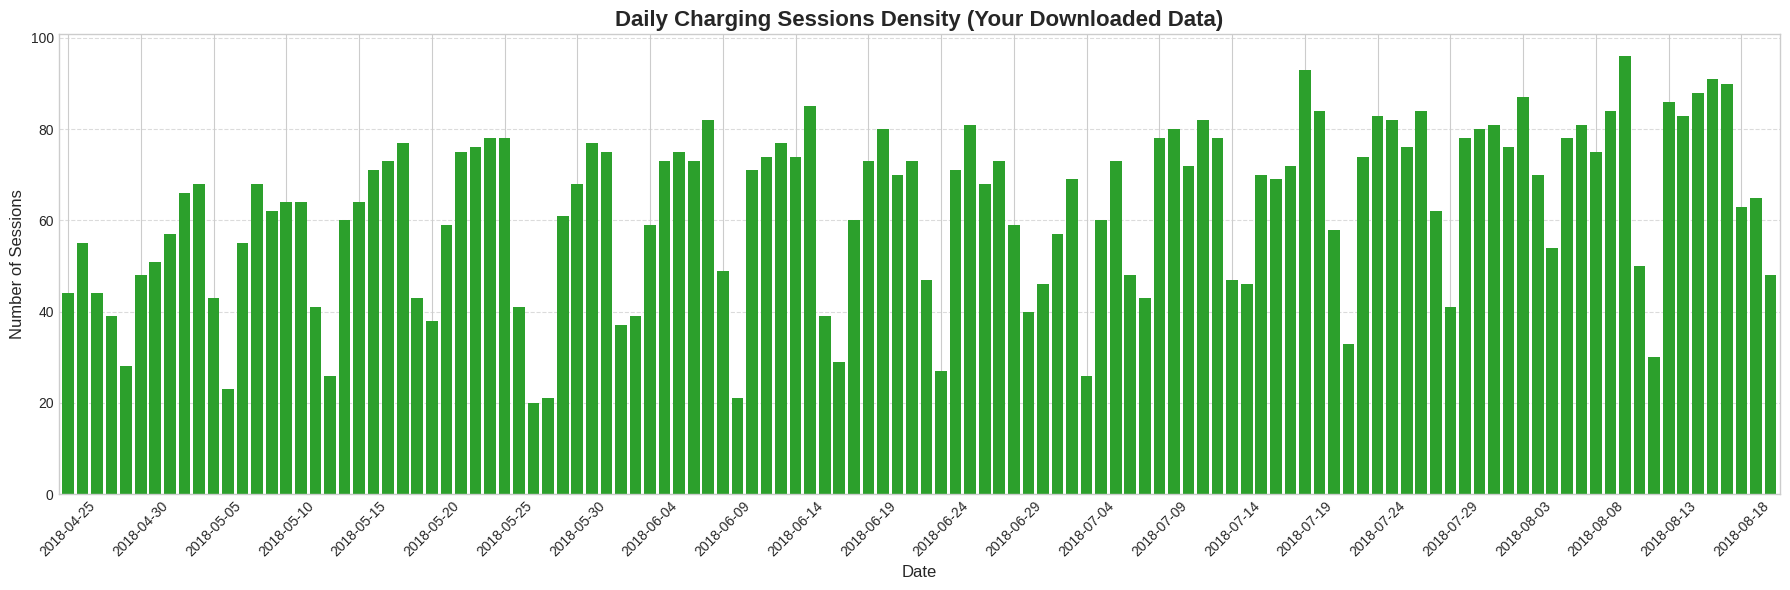

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# Pointing to the exact file you uploaded
DATA_DIR = '/content/drive/MyDrive/bescom_dataset'
file_path = f'{DATA_DIR}/acn_sessions.json'

print("Loading your JSON data...")
try:
    with open(file_path, 'r') as f:
        raw_data = json.load(f)

    data_list = raw_data.get('_items', raw_data) if isinstance(raw_data, dict) else raw_data
    df = pd.DataFrame(data_list)

    if len(df) == 0:
        print("❌ Error: File is empty.")
    else:
        # Convert connectionTime to datetime
        df['connectionTime'] = pd.to_datetime(df['connectionTime']).dt.tz_localize(None)

        # Extract just the Date (YYYY-MM-DD)
        df['Date'] = df['connectionTime'].dt.date

        # Count sessions per day
        daily_counts = df.groupby('Date').size()

        # 1. Print the Day-by-Day text list
        print(f"\n--- Day-by-Day Session Count ({len(daily_counts)} unique days) ---")
        # Force Pandas to print all rows instead of cutting off the middle
        with pd.option_context('display.max_rows', None):
            print(daily_counts)

        # 2. Plot a Bar Chart for quick visual inspection
        print("\nGenerating visual breakdown...")
        plt.figure(figsize=(18, 6))
        daily_counts.plot(kind='bar', color='#2ca02c', width=0.8)

        plt.title('Daily Charging Sessions Density (Your Downloaded Data)', fontsize=16, fontweight='bold')
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Number of Sessions', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Only show every 5th date label so the x-axis doesn't become a black smear
        plt.xticks(ticks=range(0, len(daily_counts), 5),
                   labels=[daily_counts.index[i] for i in range(0, len(daily_counts), 5)],
                   rotation=45)

        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"❌ Error reading data: {e}")

1. Loading and Analyzing JSON Boundaries...
   -> Real Data Starts: 2018-04-25 11:08:04
   -> Real Data Ends:   2018-08-20 15:53:31

2. Building Continuous Physical Reality (Hourly Load)...

3. Training Prophet (Strict Mode)...

4. Generating 7-Day Future Forecast...

5. Rendering Dashboards...


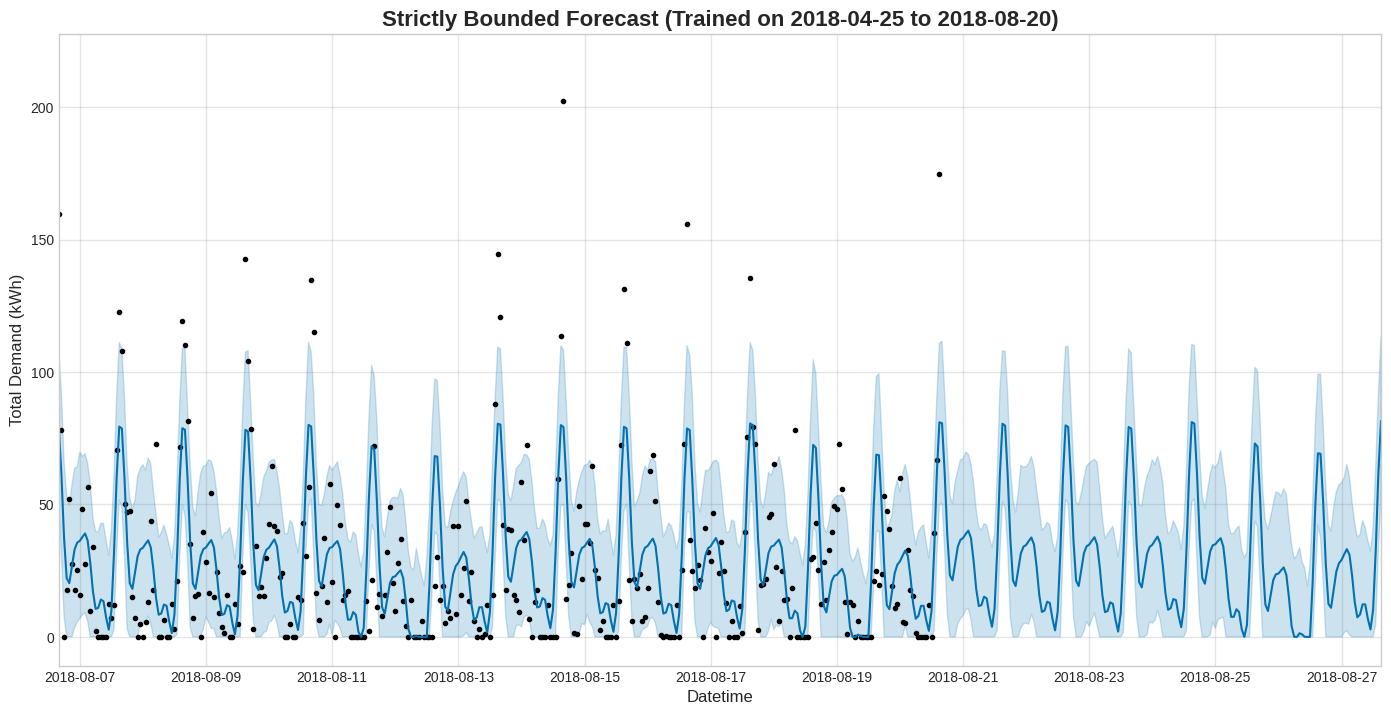

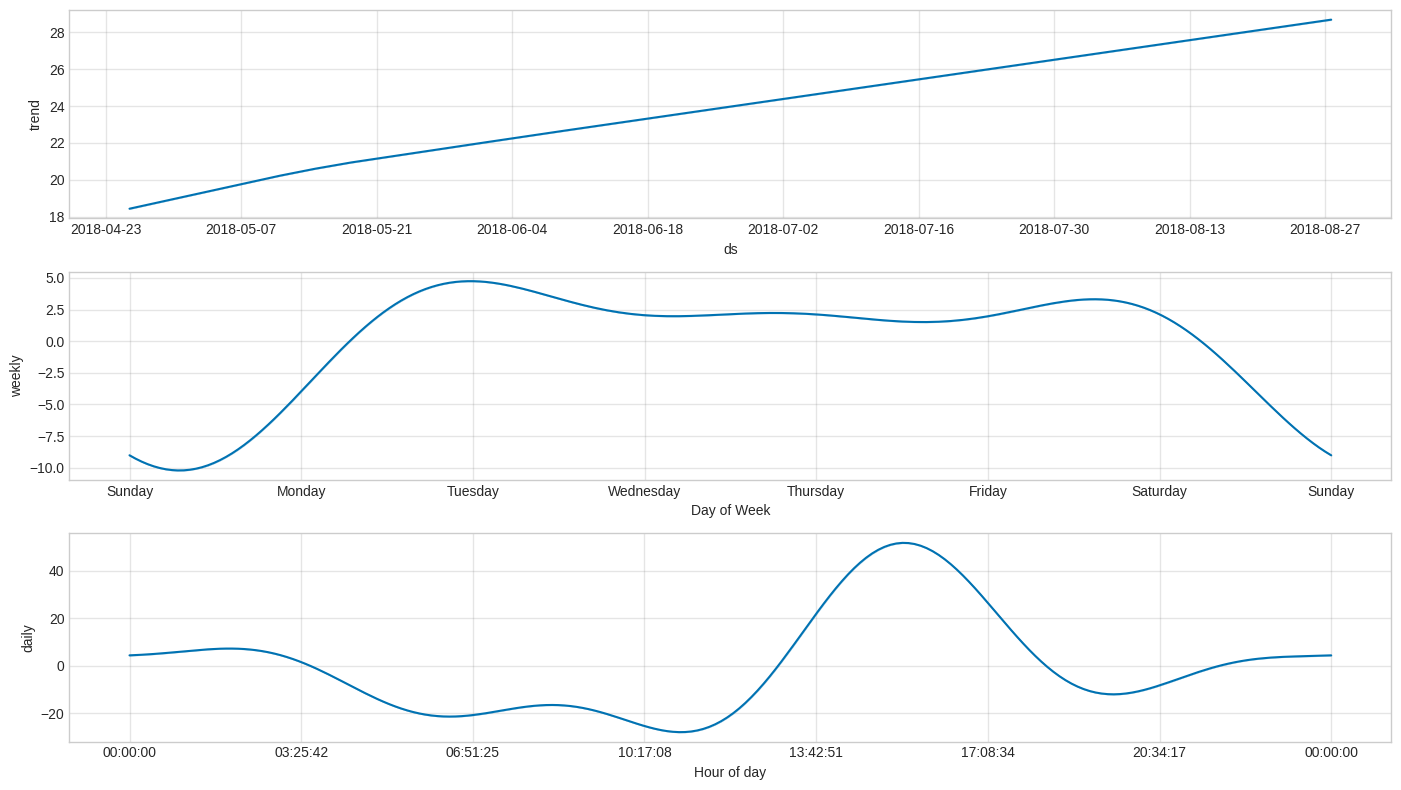

In [ ]:
# CELL: OPTICHARGE AI - STRICTLY BOUNDED TIME SERIES MODEL
!pip install -q prophet pandas matplotlib

import pandas as pd
import json
import matplotlib.pyplot as plt
from prophet import Prophet

DATA_DIR = '/content/drive/MyDrive/bescom_dataset'
file_path = f'{DATA_DIR}/acn_sessions.json'

print("1. Loading and Analyzing JSON Boundaries...")
with open(file_path, 'r') as f:
    raw_data = json.load(f)

data_list = raw_data.get('_items', raw_data) if isinstance(raw_data, dict) else raw_data
df = pd.DataFrame(data_list)

# Convert to standard datetime and sort chronologically
df['connectionTime'] = pd.to_datetime(df['connectionTime']).dt.tz_localize(None)
df.dropna(subset=['connectionTime'], inplace=True)
df = df.sort_values('connectionTime')

# Dynamically lock in the EXACT start and end of your real data
actual_start = df['connectionTime'].min()
actual_end = df['connectionTime'].max()
print(f"   -> Real Data Starts: {actual_start}")
print(f"   -> Real Data Ends:   {actual_end}")

print("\n2. Building Continuous Physical Reality (Hourly Load)...")
df.set_index('connectionTime', inplace=True)
# This command adds 0s ONLY to the hours between your start and end date where no cars charged.
# It does NOT add fake data outside your timeframe.
df_hourly = df['kWhDelivered'].resample('h').sum().fillna(0).reset_index()
df_hourly.rename(columns={'connectionTime': 'ds', 'kWhDelivered': 'y'}, inplace=True)

print("\n3. Training Prophet (Strict Mode)...")
# We explicitly forbid the AI from guessing yearly (winter) trends it has never seen.
m = Prophet(
    weekly_seasonality=True,  # Look at actual Weekdays vs Weekends
    daily_seasonality=True,   # Look at actual Morning vs Evening
    yearly_seasonality=False, # STRICTLY FALSE: Do not guess outside the 118 days
    changepoint_prior_scale=0.05
)

m.fit(df_hourly)

print("\n4. Generating 7-Day Future Forecast...")
future = m.make_future_dataframe(periods=168, freq='h')
forecast = m.predict(future)

# Guardrail: The physics of the grid dictates demand cannot drop below 0 kWh.
forecast['yhat'] = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)

# Save the pure forecast payload
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(168)
forecast_output.to_csv(f'{DATA_DIR}/opticharge_7day_forecast.csv', index=False)

print("\n5. Rendering Dashboards...")
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

# Main Forecast Plot
fig1 = m.plot(forecast, figsize=(14, 7))
plt.title(f"Strictly Bounded Forecast (Trained on {actual_start.date()} to {actual_end.date()})", fontsize=16, fontweight='bold')
plt.xlabel("Datetime", fontsize=12)
plt.ylabel("Total Demand (kWh)", fontsize=12)

# Zoom in so you can actually see the hourly curves (last 14 days of data + 7 days future)
zoom_start = forecast['ds'].iloc[-504]
zoom_end = forecast['ds'].iloc[-1]
plt.xlim([zoom_start, zoom_end])
plt.show()

# Components Plot
fig2 = m.plot_components(forecast, figsize=(14, 8))
plt.show()